<a href="https://colab.research.google.com/github/guptaankit894/AAIM/blob/main/google_colab_files/GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

In [3]:
#Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
latent_dim = 100
lr = 0.0002
num_epochs = 20

os.makedirs("generated_images", exist_ok=True)

In [4]:
# Get Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # scale to [-1, 1]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [5]:
#Generator

class Generator(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 256),
            nn.ReLU(inplace=True),

            nn.Linear(256, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, 784),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.model(z)
        return x.view(-1, 1, 28, 28)



 # Discriminator

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(-1, 784)
        return self.model(x)


In [6]:
#Models Initialisation
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Fixed noise for monitoring progress
fixed_noise = torch.randn(16, latent_dim, device=device)

In [7]:
# visualize generated images during training process
def show_generated_images(epoch: int, generator: nn.Module, noise: torch.Tensor) -> None:
    generator.eval()
    with torch.no_grad():
        fake_images = generator(noise).cpu()

    grid = make_grid(fake_images, nrow=4, normalize=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze())
    plt.title(f"Generated Images at Epoch {epoch}")
    plt.axis("off")
    plt.show()

    generator.train()

Epoch [1/20] | D Loss: 0.8260 | G Loss: 1.5023


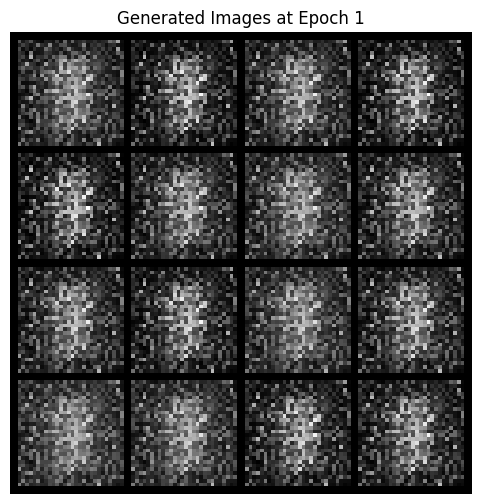

Epoch [2/20] | D Loss: 0.4763 | G Loss: 3.3569
Epoch [3/20] | D Loss: 0.3952 | G Loss: 3.9382
Epoch [4/20] | D Loss: 0.3677 | G Loss: 4.4735
Epoch [5/20] | D Loss: 0.3188 | G Loss: 4.5091


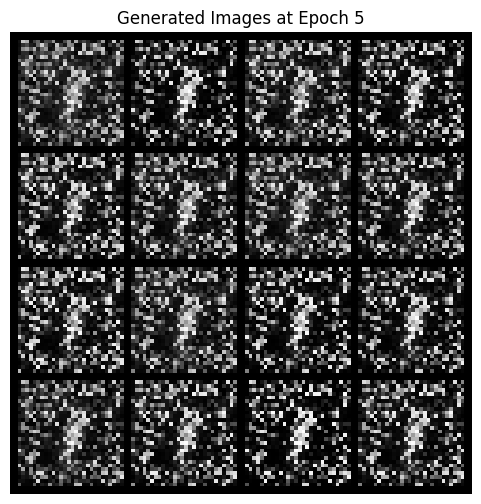

Epoch [6/20] | D Loss: 0.3780 | G Loss: 4.4635
Epoch [7/20] | D Loss: 0.3001 | G Loss: 4.8986
Epoch [8/20] | D Loss: 0.2725 | G Loss: 5.1797
Epoch [9/20] | D Loss: 0.2432 | G Loss: 4.9335
Epoch [10/20] | D Loss: 0.2788 | G Loss: 5.2883


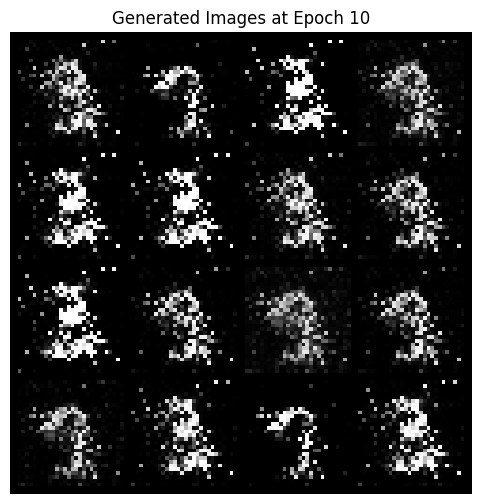

Epoch [11/20] | D Loss: 0.2478 | G Loss: 4.8433
Epoch [12/20] | D Loss: 0.2497 | G Loss: 5.2225
Epoch [13/20] | D Loss: 0.3200 | G Loss: 4.0890
Epoch [14/20] | D Loss: 0.3504 | G Loss: 3.7379
Epoch [15/20] | D Loss: 0.2297 | G Loss: 4.1754


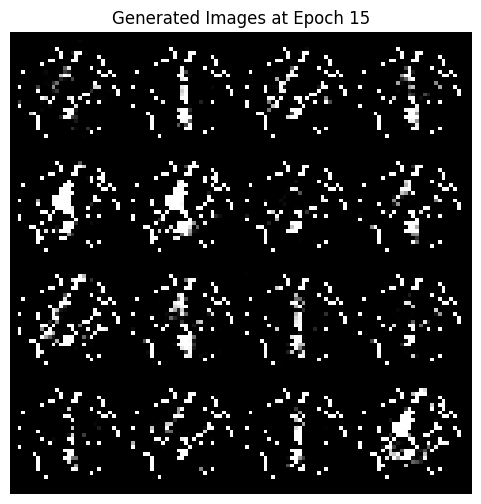

Epoch [16/20] | D Loss: 0.2429 | G Loss: 5.4015
Epoch [17/20] | D Loss: 0.2862 | G Loss: 3.8147
Epoch [18/20] | D Loss: 0.2240 | G Loss: 5.7338
Epoch [19/20] | D Loss: 0.3306 | G Loss: 3.5228
Epoch [20/20] | D Loss: 0.3546 | G Loss: 3.9112


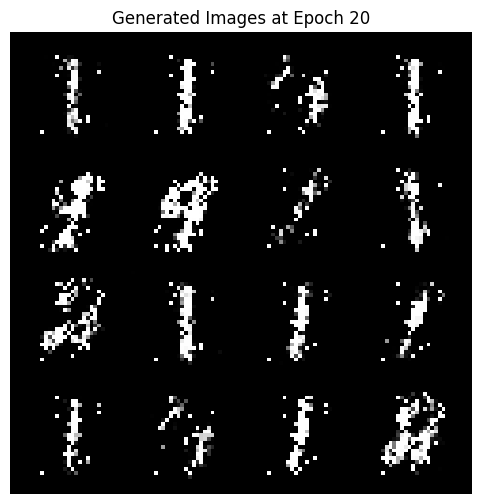

In [8]:
# Training Process
for epoch in range(num_epochs):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        batch_size_curr = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size_curr, 1, device=device)
        fake_labels = torch.zeros(batch_size_curr, 1, device=device)

        # ---------------------------------
        # Train Discriminator
        # ---------------------------------
        optimizer_D.zero_grad()

        # Real images
        real_outputs = discriminator(real_images)
        d_loss_real = criterion(real_outputs, real_labels)

        # Fake images
        z = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_images = generator(z)
        fake_outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ---------------------------------
        # Train Generator
        # ---------------------------------
        optimizer_G.zero_grad()

        z = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_images = generator(z)
        outputs = discriminator(fake_images)

        # Generator wants discriminator to classify fakes as real
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    avg_g = g_loss_epoch / len(train_loader)
    avg_d = d_loss_epoch / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")

    if (epoch + 1) % 5 == 0 or epoch == 0:
        show_generated_images(epoch + 1, generator, fixed_noise)




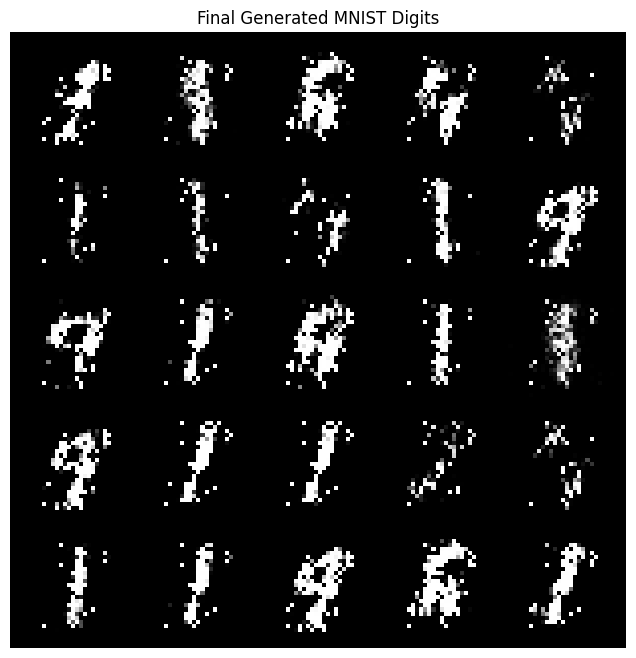

In [9]:
# Visualise generation

generator.eval()
with torch.no_grad():
    z = torch.randn(25, latent_dim, device=device)
    generated = generator(z).cpu()

grid = make_grid(generated, nrow=5, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze())
plt.title("Final Generated MNIST Digits")
plt.axis("off")
plt.show()